<a href="https://colab.research.google.com/github/IvanovaKaryna/-/blob/main/%D0%9B%D0%912_%D0%86%D0%B2%D0%B0%D0%BD%D0%BE%D0%B2%D0%B0_3_10_%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_1_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Іванова, ФІТ 3-10

---



# Завдання 1

**Був присутній на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [18]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"

html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text
tables = pd.read_html(html)
df = tables[2]
df.head()

/tmp/ipykernel_13630/3091407980.py:8: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


In [19]:
df.columns

Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')

2.	Визначити розмір датасета.

In [20]:
df.shape

(222, 4)

 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [21]:
df.columns

Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')

4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [22]:
df = df.replace("—", np.nan)

print("Пропущені значення до заповнення:")
print(df.isnull().sum())

for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.iloc[:, 1:] = df.iloc[:, 1:].fillna(df.iloc[:, 1:].mean())

print("\nПропущені значення після заповнення:")
print(df.isnull().sum())

Пропущені значення до заповнення:
Country/Territory           0
IMF (2026)[1]               0
World Bank (2025)[6]        0
United Nations (2024)[7]    0
dtype: int64

Пропущені значення після заповнення:
Country/Territory           0
IMF (2026)[1]               0
World Bank (2025)[6]        0
United Nations (2024)[7]    0
dtype: int64


5. Ще раз вивести датасет

In [23]:
df

,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,1.262953e+08,1.183502e+08,111565144.0
1,United States,3.238392e+07,3.076970e+07,29298000.0
2,China[n 1],2.085159e+07,1.949804e+07,18743802.0
3,Germany,5.452858e+06,5.050923e+06,4659929.0
4,Japan,4.379253e+06,4.435163e+06,4026211.0
...,...,...,...,...
217,Palau,3.770000e+02,3.450000e+02,310.0
218,Marshall Islands,3.420000e+02,3.080000e+02,281.0
219,Nauru,1.960000e+02,1.760000e+02,187.0
220,Montserrat,1.319229e+06,1.255590e+06,81.0


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [24]:
print("Кількість дублікатів:", df.duplicated().sum())

Кількість дублікатів: 0


In [25]:
df = df.drop_duplicates()

In [26]:
print("Кількість дублікатів після видалення:", df.duplicated().sum())

Кількість дублікатів після видалення: 0


7.	Вивести описову статистику датасету describe()

In [27]:
df.describe()

,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
count,2.220000e+02,2.220000e+02,2.220000e+02
mean,1.319229e+06,1.255590e+06,1.043818e+06
std,8.838876e+06,8.288461e+06,7.830341e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,1.932375e+04,2.003400e+04,9.170750e+03
50%,1.039745e+05,9.986350e+04,4.322450e+04
75%,7.726678e+05,1.041520e+06,3.048545e+05
max,1.262953e+08,1.183502e+08,1.115651e+08


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [28]:
df["Difference"] = abs(
    df["IMF (2026)[1]"] - df["World Bank (2025)[6]"]
)

result = df[["Country/Territory", "Difference"]].sort_values(
    "Difference", ascending=False
)

result.head()

,Country/Territory,Difference
0,World,7.945165e+06
1,United States,1.614220e+06
2,China[n 1],1.353554e+06
197,Sint Maarten,1.317341e+06
146,Palestine[n 11][n 12],1.302062e+06


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [29]:
df[
    [
        "IMF (2026)[1]",
        "World Bank (2025)[6]",
        "United Nations (2024)[7]"
    ]
].corr()

,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
IMF (2026)[1],1.000000,0.999497,0.998998
World Bank (2025)[6],0.999497,1.000000,0.998864
United Nations (2024)[7],0.998998,0.998864,1.000000


Обчислити середнє значення за стовпцями

In [30]:
df[
    [
        "IMF (2026)[1]",
        "World Bank (2025)[6]",
        "United Nations (2024)[7]"
    ]
].mean()

,0
IMF (2026)[1],1.319229e+06
World Bank (2025)[6],1.255590e+06
United Nations (2024)[7],1.043818e+06


11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [31]:
df["Std"] = df[
    [
        "IMF (2026)[1]",
        "World Bank (2025)[6]",
        "United Nations (2024)[7]"
    ]
].std(axis=1)
df[
    ["Country/Territory", "Std"]
].sort_values(
    "Std",
    ascending=False
).head()

,Country/Territory,Std
0,World,7.372704e+06
1,United States,1.543508e+06
2,China[n 1],1.068002e+06
197,Sint Maarten,7.606303e+05
146,Palestine[n 11][n 12],7.520782e+05


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [32]:
for col in [
    "IMF (2026)[1]",
    "World Bank (2025)[6]",
    "United Nations (2024)[7]"
]:
    print("\n", col)

    print(
        "Найвищий:",
        df.loc[df[col].idxmax(), "Country/Territory"],
        df[col].max()
    )

    print(
        "Найнижчий:",
        df.loc[df[col].idxmin(), "Country/Territory"],
        df[col].min()
    )


 IMF (2026)[1]
Найвищий: World 126295331.0
Найнижчий: Tuvalu 65.0

 World Bank (2025)[6]
Найвищий: World 118350166.0
Найнижчий: Tuvalu 57.0

 United Nations (2024)[7]
Найвищий: World 111565144.0
Найнижчий: Tuvalu 56.0


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

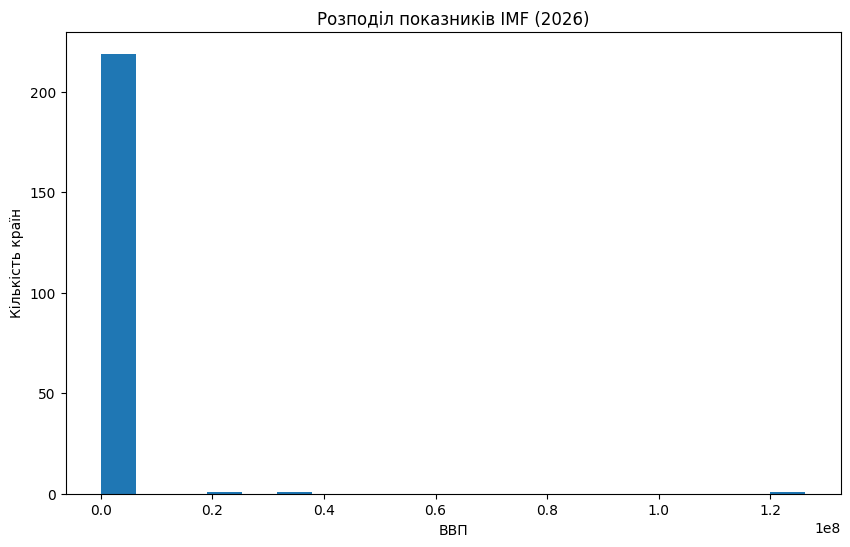

In [33]:
plt.figure(figsize=(10, 6))

plt.hist(df["IMF (2026)[1]"], bins=20)

plt.title("Розподіл показників IMF (2026)")
plt.xlabel("ВВП")
plt.ylabel("Кількість країн")

plt.show()

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [35]:
df["Share IMF"] = (
    df["IMF (2026)[1]"] /
    df["IMF (2026)[1]"].sum()
) * 100

df["Share World Bank"] = (
    df["World Bank (2025)[6]"] /
    df["World Bank (2025)[6]"].sum()
) * 100

df["Share UN"] = (
    df["United Nations (2024)[7]"] /
    df["United Nations (2024)[7]"].sum()
) * 100
df[
    [
        "Country/Territory",
        "Share IMF",
        "Share World Bank",
        "Share UN"
    ]
]

,Country/Territory,Share IMF,Share World Bank,Share UN
0,World,43.123505,42.458818,48.144944
1,United States,11.057480,11.038811,12.643291
2,China[n 1],7.119770,6.995036,8.088721
3,Germany,1.861877,1.812048,2.010951
4,Japan,1.495295,1.591141,1.737475
...,...,...,...,...
217,Palau,0.000129,0.000124,0.000134
218,Marshall Islands,0.000117,0.000110,0.000121
219,Nauru,0.000067,0.000063,0.000081
220,Montserrat,0.450450,0.450450,0.000035


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

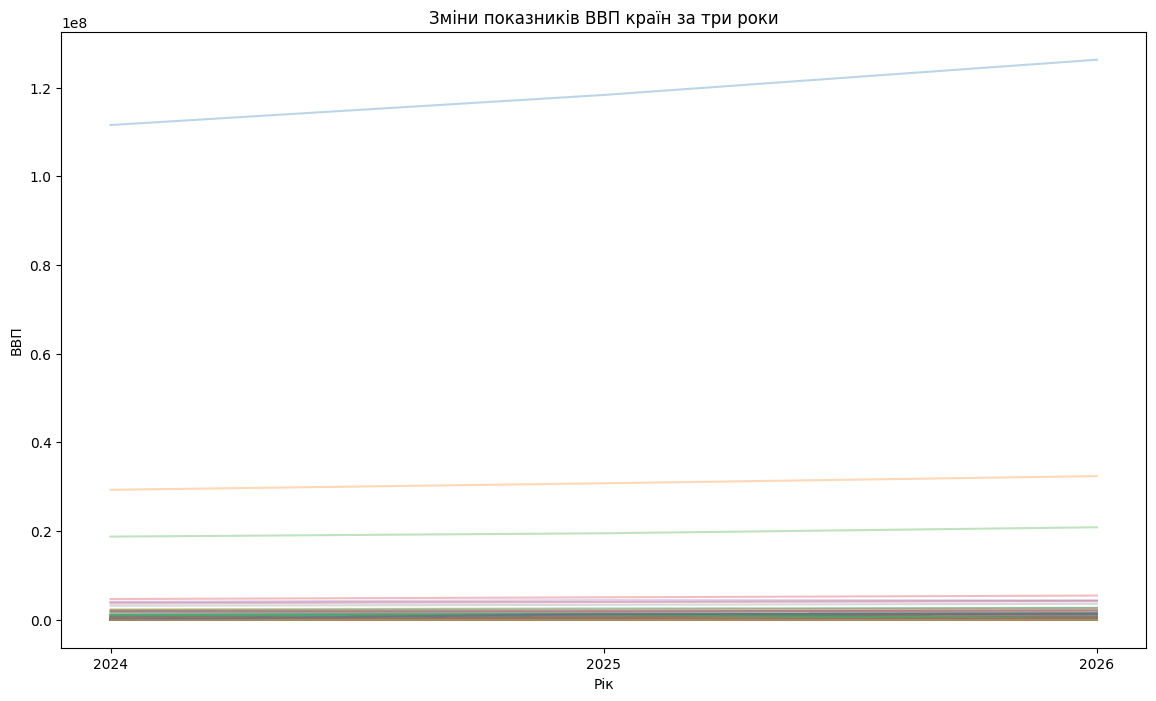

Стабільне зростання:
['World', 'United States', 'China[n 1]', 'Germany', 'United Kingdom', 'India', 'France', 'Italy', 'Russia', 'Brazil', 'Canada', 'Spain', 'Turkey', 'Indonesia', 'Netherlands', 'Saudi Arabia', 'Switzerland', 'Poland', 'Ireland', 'Belgium', 'Sweden', 'Israel', 'Argentina', 'Singapore', 'Austria', 'Norway', 'Thailand', 'Colombia', 'Vietnam', 'Malaysia', 'Philippines', 'Bangladesh', 'Denmark', 'Romania', 'South Africa', 'Hong Kong[n 4]', 'Czech Republic', 'Egypt', 'Chile', 'Pakistan', 'Peru', 'Portugal', 'Nigeria', 'Kazakhstan', 'Finland', 'Algeria', 'Greece', 'New Zealand', 'Hungary', 'Cuba', 'Ukraine[n 5]', 'Morocco', 'Uzbekistan', 'Slovakia', 'Angola', 'Bulgaria', 'Kenya', 'Ecuador', 'Dominican Republic', 'Guatemala', 'DR Congo', 'Ghana', 'Oman', 'Croatia', 'Ivory Coast', 'Serbia', 'Luxembourg', 'Costa Rica', 'Sri Lanka', 'Lithuania', 'Belarus', 'Uruguay', 'Panama', 'Tanzania[n 6]', 'Slovenia', 'Myanmar', 'Bolivia', 'Azerbaijan', 'Uganda', 'Cameroon', 'Jordan', 'Tuni

In [37]:
plt.figure(figsize=(14, 8))

for _, row in df.iterrows():
    plt.plot(
        ["2024", "2025", "2026"],
        [
            row["United Nations (2024)[7]"],
            row["World Bank (2025)[6]"],
            row["IMF (2026)[1]"]
        ],
        alpha=0.3
    )

plt.title("Зміни показників ВВП країн за три роки")
plt.xlabel("Рік")
plt.ylabel("ВВП")

plt.show()
growth = df[
    (df["United Nations (2024)[7]"] < df["World Bank (2025)[6]"]) &
    (df["World Bank (2025)[6]"] < df["IMF (2026)[1]"])
]

decline = df[
    (df["United Nations (2024)[7]"] > df["World Bank (2025)[6]"]) &
    (df["World Bank (2025)[6]"] > df["IMF (2026)[1]"])
]

print("Стабільне зростання:")
print(growth["Country/Territory"].tolist())

print("\nСтабільний спад:")
print(decline["Country/Territory"].tolist())